### K-Means Model

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn import metrics

In [107]:
data = pd.read_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/clean_data.csv')
test_data = pd.read_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/test_data.csv')

In [108]:
data = data.drop(columns=('Unnamed: 0'))
data.head()

,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,...,sadness,feelings,age,genre_blues,genre_country,genre_hip hop,genre_jazz,genre_pop,genre_reggae,genre_rock
0,0.000598,0.063746,0.000598,0.000598,0.000598,0.048857,0.017104,0.263751,0.000598,0.039288,...,0.380299,0.117175,1.0,0,0,0,0,1,0,0
1,0.035537,0.096777,0.443435,0.001284,0.001284,0.027007,0.001284,0.001284,0.001284,0.118034,...,0.001284,0.001284,1.0,0,0,0,0,1,0,0
2,0.002770,0.002770,0.002770,0.002770,0.002770,0.002770,0.158564,0.250668,0.002770,0.323794,...,0.002770,0.225422,1.0,0,0,0,0,1,0,0
3,0.048249,0.001548,0.001548,0.001548,0.021500,0.001548,0.411536,0.001548,0.001548,0.001548,...,0.225889,0.001548,1.0,0,0,0,0,1,0,0
4,0.001350,0.001350,0.417772,0.001350,0.001350,0.001350,0.463430,0.001350,0.001350,0.001350,...,0.068800,0.001350,1.0,0,0,0,0,1,0,0


In order to find the optimal number of clusters, I am going to use two plots and cross-reference the results: an elbow plot & a silhouette plot. Values with low sum of squares on the elbow plot are better for our model. Values with a higher silhouette score are also good for our model.

First we will create the elbow plot:

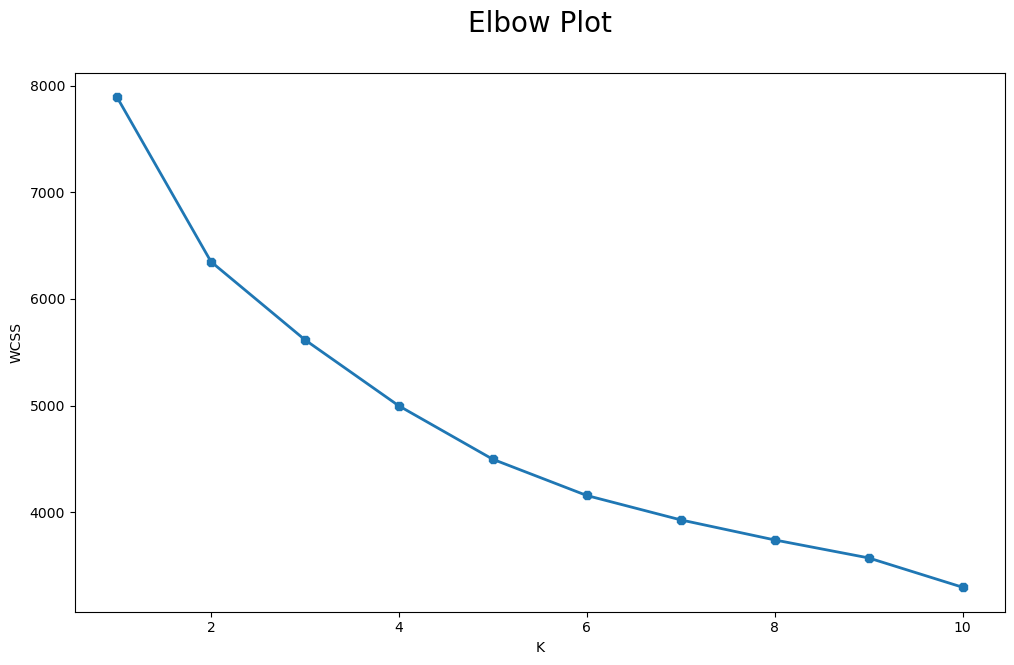

In [109]:
#The genre column was dominating the clustering so it will not be fed into the model
X1 = data.loc[:, ['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music',
       'movement/places', 'light/visual perceptions', 'family/spiritual',
       'sadness', 'feelings', 'age']].values

wcss= []
for k in range(1, 11):
    #create a Kmeans object initialized with `k` clusters and `init` parameter of `k-means++`

    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    kmeans.fit(X1)
    wcss.append(kmeans.inertia_)

plt.figure(figsize = (12, 7))

plt.plot(range(1, 11), wcss, linewidth = 2, marker = '8')
plt.title('Elbow Plot\n', fontsize = 20)
plt.xlabel('K')
plt.ylabel('WCSS')
plt.show()

Our optimal k seems to lie between 5 and 8. I'll run a Silhoutte plot to compare.

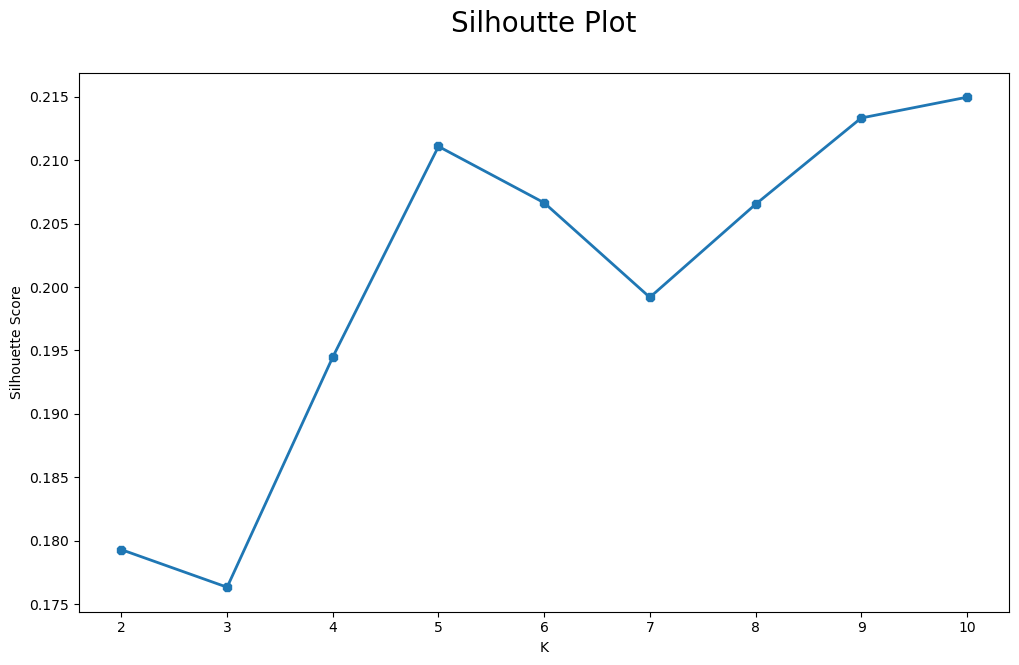

In [110]:
silhouette = []
for k in range(2, 11):
    #create a Kmeans object initialized with `k` clusters and `init` parameter of `k-means++`
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    predictions = kmeans.fit_predict(X1)
    silhouette.append(metrics.silhouette_score(X1, predictions))

plt.figure(figsize = (12, 7))

plt.plot(range(2, 11), silhouette, linewidth = 2, marker = '8')
plt.title('Silhoutte Plot\n', fontsize = 20)
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.show()

Silhoutte plot points to 5 or 6 being our most optimal number of k's. Because it falls in the previous range and provides more representation 6 is the number I will move forward with.

In [111]:
#creat kmeans object
k_means = KMeans(n_clusters=6, init='k-means++')
#fit to our data
k_means.fit(X1)

KMeans(n_clusters=6)

In [112]:
#produce labels based on our clusters
labels = k_means.fit_predict(X1)
#apply these labels to our data
data['labels'] = labels
#view our cluster sizes
data['labels'].value_counts()

labels
3    6297
1    5381
5    5309
2    4639
4    4441
0    2295
Name: count, dtype: int64

Similar amounts in each cluster is a great sign for this model.

In [113]:
# output the centroids of clusters
k_means.cluster_centers_

array([[0.02427907, 0.03087288, 0.04013939, 0.04000041, 0.01533125,
        0.02148296, 0.03142423, 0.06165275, 0.02468585, 0.41166642,
        0.05652015, 0.06414375, 0.0281835 , 0.04392853, 0.02491018,
        0.52638655],
       [0.02322817, 0.03996114, 0.04755893, 0.07876137, 0.01623451,
        0.01397726, 0.05237086, 0.08839558, 0.01776576, 0.02839998,
        0.03751959, 0.04698898, 0.0192987 , 0.36508363, 0.03549722,
        0.29465215],
       [0.01633153, 0.04311708, 0.42859139, 0.0396456 , 0.01625324,
        0.01468703, 0.0332684 , 0.07411265, 0.0217183 , 0.02733403,
        0.04246646, 0.0517852 , 0.02807599, 0.05490247, 0.02810844,
        0.36963863],
       [0.0294794 , 0.05739934, 0.10156637, 0.09035088, 0.01457481,
        0.02133077, 0.10809693, 0.08506513, 0.05053626, 0.03991472,
        0.04155231, 0.05397773, 0.02372747, 0.15894296, 0.0434792 ,
        0.75180217],
       [0.01974675, 0.05010358, 0.04068483, 0.03327089, 0.02586087,
        0.01675832, 0.01432219, 

These center clusters are datapoints that have been chosen as the most representivitve of the cluster, with each value in the array cooresponding to a column in our dataframe. That means that if we can evaluate how these relate to each other and our standard dataset, we can determine the qualities of the cluster. That lets us define our outputs.

Let me start by creating a visualization for the data

<Axes: >

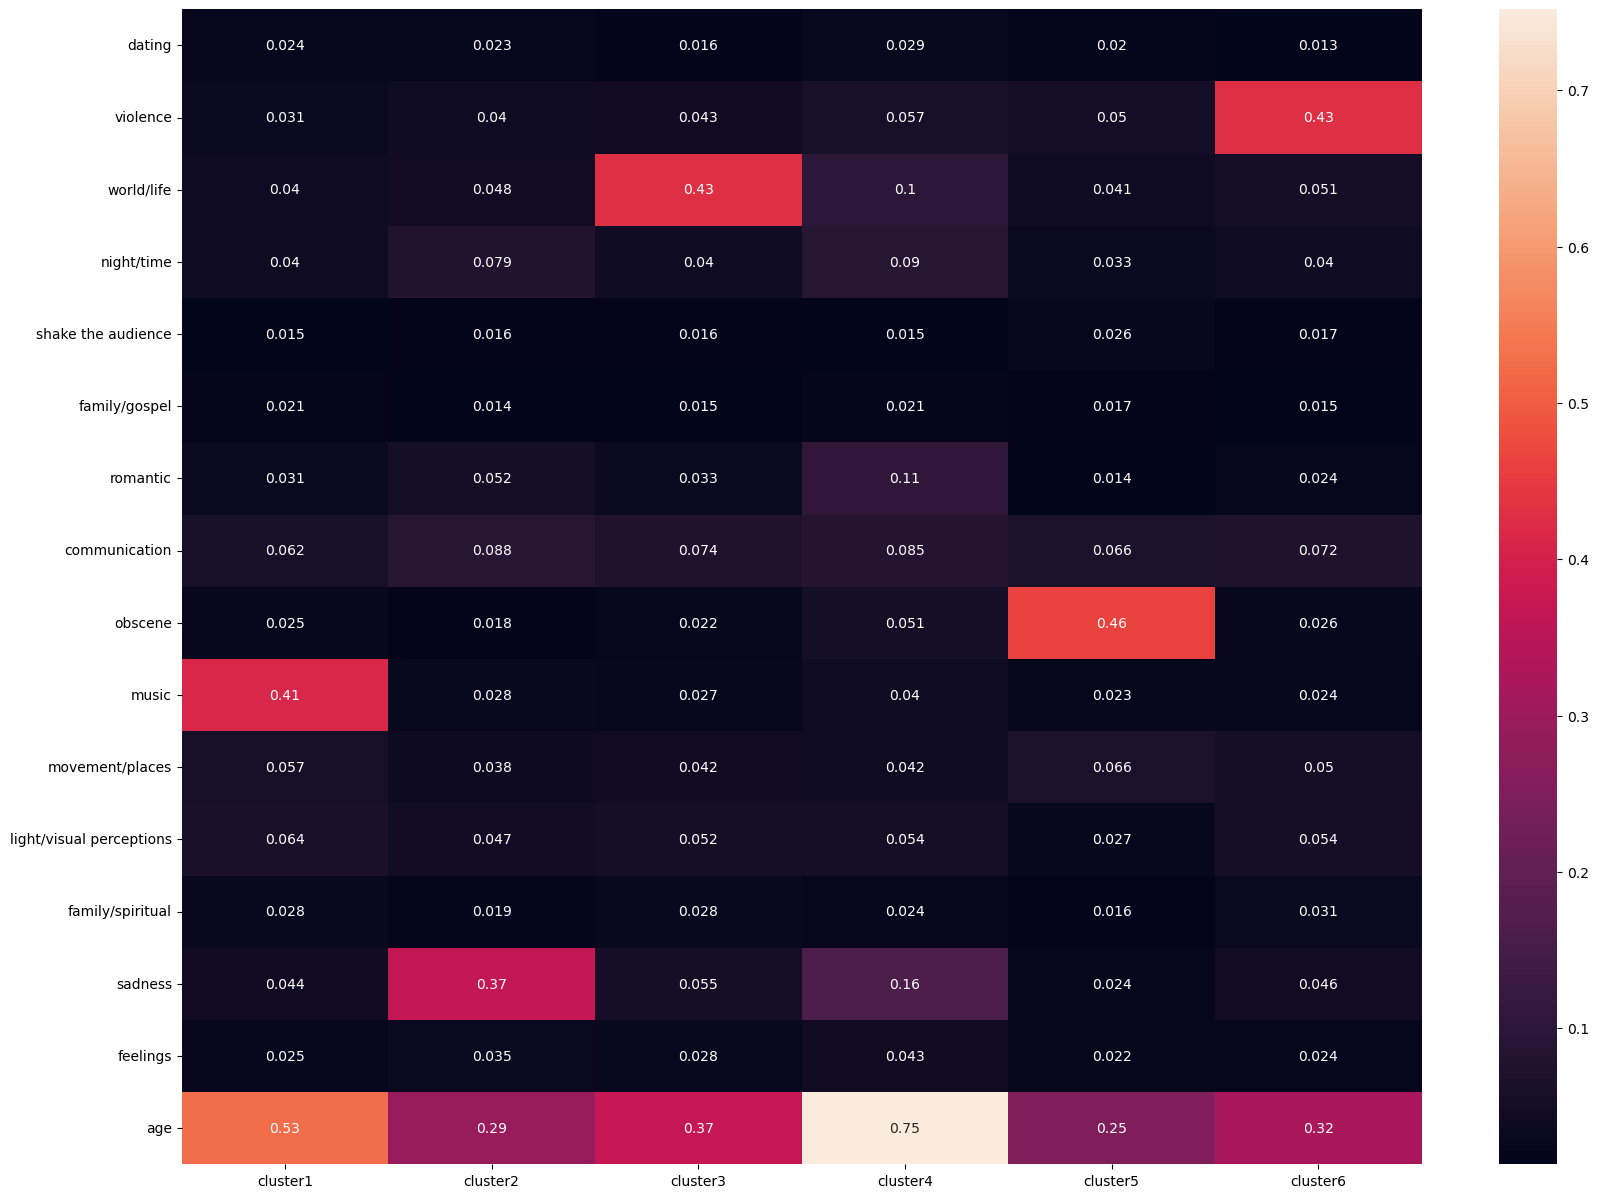

In [114]:
#empty dataframe with clusters as columns and each column, in proper order, as the index
clusters = pd.DataFrame(columns=['cluster1','cluster2','cluster3','cluster4','cluster5','cluster6'], index=['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music','movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'age'])
#putting in the appropriate data
clusters['cluster1'] = k_means.cluster_centers_[0]
clusters['cluster2'] = k_means.cluster_centers_[1]
clusters['cluster3'] = k_means.cluster_centers_[2]
clusters['cluster4'] = k_means.cluster_centers_[3]
clusters['cluster5'] = k_means.cluster_centers_[4]
clusters['cluster6'] = k_means.cluster_centers_[5]
#plot a visualization
plt.figure(figsize=(20,15))
sns.heatmap(clusters, annot=True)

This is the meat of our model. These are the most representitive samples of each cluster. If I can create another column with the means of each row across the whole dataset, I can see if there is another aspect to some of the less deinfed clusters.

In [115]:
cols = ['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music',
       'movement/places', 'light/visual perceptions', 'family/spiritual',
       'sadness', 'feelings', 'age']
means = []
for val in cols:
    v = []
    for x in data[val]:
        v.append(x)
    avg = sum(v) / len(v)
    means.append(avg)
clusters['means'] = means
clusters

,cluster1,cluster2,cluster3,cluster4,cluster5,cluster6,means
dating,0.024279,0.023228,0.016332,0.029479,0.019747,0.012988,0.021110
violence,0.030873,0.039961,0.043117,0.057399,0.050104,0.431004,0.118371
world/life,0.040139,0.047559,0.428591,0.101566,0.040685,0.051368,0.120984
night/time,0.040000,0.078761,0.039646,0.090351,0.033271,0.039686,0.057356
shake the audience,0.015331,0.016235,0.016253,0.014575,0.025861,0.016849,0.017418
family/gospel,0.021483,0.013977,0.014687,0.021331,0.016758,0.015457,0.017045
romantic,0.031424,0.052371,0.033268,0.108097,0.014322,0.024151,0.048676
communication,0.061653,0.088396,0.074113,0.085065,0.066481,0.071981,0.076651
obscene,0.024686,0.017766,0.021718,0.050536,0.460967,0.026009,0.097185
music,0.411666,0.028400,0.027334,0.039915,0.022561,0.024055,0.060067


<Axes: >

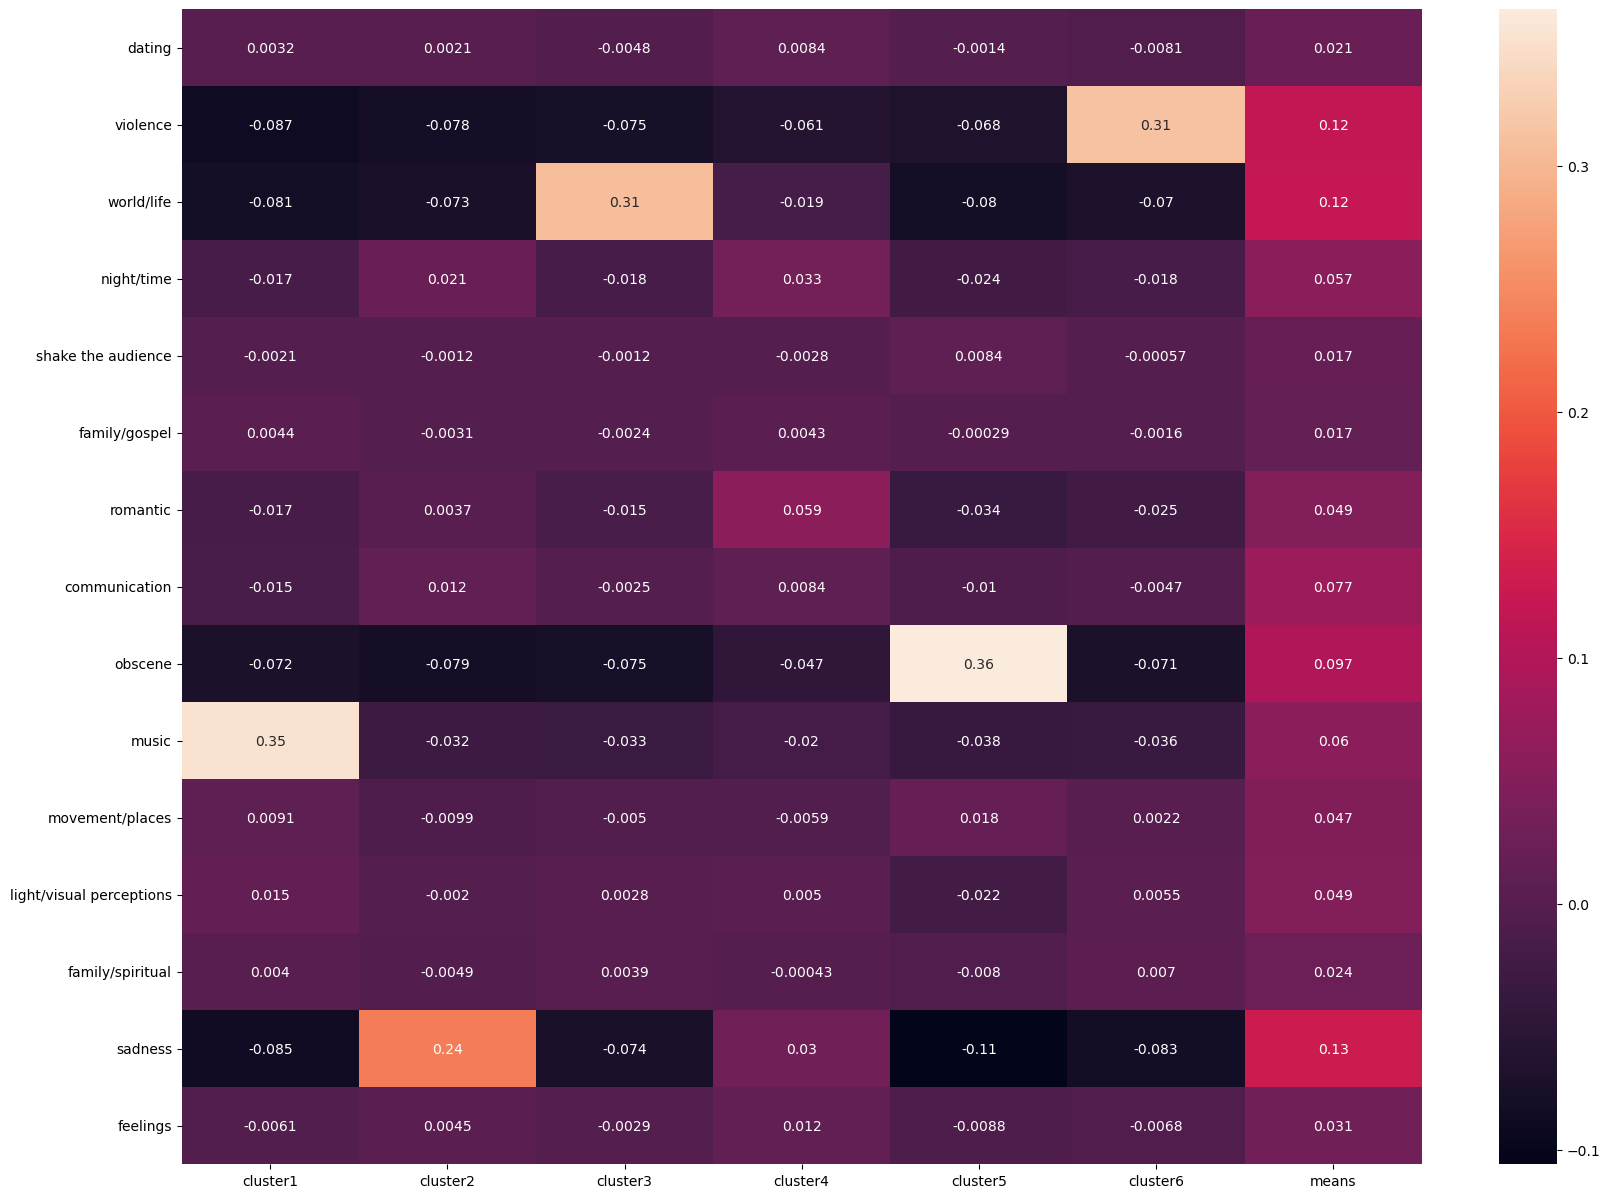

In [116]:
clusters = clusters.drop('age')
#remake the df replacing the value 
clusters['cluster1'] = (clusters['cluster1'] - clusters['means'])
clusters['cluster2'] = (clusters['cluster2'] - clusters['means'])
clusters['cluster3'] = (clusters['cluster3'] - clusters['means'])
clusters['cluster4'] = (clusters['cluster4'] - clusters['means'])
clusters['cluster5'] = (clusters['cluster5'] - clusters['means'])
clusters['cluster6'] = (clusters['cluster6'] - clusters['means'])
#plot a visualization
plt.figure(figsize=(20,15))
sns.heatmap(clusters, annot=True)

The heatmap of how much the cluster values deviate from the mean doesn't provide much more desciption than our previous heatmap. Combining the information from the 2 we can now define our clusters. 

# Model Evaluation
The heatmaps above show that single features may be dominating clusters, leading to very general ways to descibe them. Let's have some fun and create playlist names for these clusters: 

### Cluster 1: Human Music (high in World/Life)

### Cluster 2: Oldies (high in age)

### Cluster 3: F#%K YOU (high in obsenity)

### Cluster 4: Sad Songs :C (high in sadness)

### Cluster 5: Meh... (songs that don't score highly in any catagory)

### Cluster 6: Looking for a Fight (high in violence)


These general labels would be good for an varied experiance across broad catagories. Users specifically looking for different sounds with a lyrical topic connecting them. If the goal is to connect the listener with something close to what they are currently listening to, this would not be a good model. The heirarchal clustering model in this folder will show a breakdown of the clustering and may provide a better way to provide a closer song match.

In [117]:
data = data[['labels']]
data.to_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/kmeans_labels.csv')

##### Example of Function

In [119]:
X2 = test_data[['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music',
       'movement/places', 'light/visual perceptions', 'family/spiritual',
       'sadness', 'feelings', 'age']]
labels2 = kmeans.fit_predict(X2)
labels2

array([6, 0, 1, 7, 2, 4, 5, 3, 9, 8], dtype=int32)